# GSHTD Threshold Variant Comparison

Compares four Tmin-based heat threshold variants across three cities:
**Salvador** and **Rio de Janeiro** (Brazil) and **Bengaluru** (India).

| Variant | Method | Percentile |
|---------|--------|------------|
| `ann_p90` | Annual P90 of Tmin (all base-period days) | 90th |
| `ann_p95` | Annual P95 of Tmin | 95th |
| `mw_p90` | Moving-window P90 (5-day centred, per DOY) | 90th |
| `mw_p95` | Moving-window P95 | 95th |

**Data source:** Zhang et al. (2022) GSHTD — 1 km daily Tmin, retrieved from  
`projects/sat-io/open-datasets/global-daily-air-temp/`

**Kernel:** `conda-env-gee-py`

---
## Workflow
1. [Configuration](#sec0)
2. [GEE Data Acquisition](#sec1) — run only if local files are missing
3. [Load & Validate Data](#sec2)
4. [Compute Thresholds](#sec3)
5. [Count Heat Days](#sec4)
6. [Zonal Aggregation to Neighbourhoods](#sec5)
7. [Analysis](#sec6) — correlation matrix, scatter plots, summary table

---
## 0. Configuration <a id='sec0'></a>

In [23]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')

# ── Base period for threshold derivation (confirm before hardcoding) ─────────
BASE_START = '2003-01-01'
BASE_END   = '2020-12-31'

# ── Single test year for heat-day counting ───────────────────────────────────
TEST_YEAR = 2019

# ── Moving-window half-width (total window = 2*HALF_W + 1 days) ─────────────
HALF_W = 2  # → 5-day centred window

# ── Paths ────────────────────────────────────────────────────────────────────
REPO_ROOT = Path('..') if Path('../data').exists() else Path('.')
DATA_DIR  = REPO_ROOT / 'data'
SHAPES_DIR = DATA_DIR / 'neighbourhoodShapes'
GEE_PROJECT = 'tl-cities'   # update to your GEE project ID if needed

# ── City registry ────────────────────────────────────────────────────────────
# GEE sub-collections (Zhang et al. GSHTD):
#   africa, australia, europe_asia, latin_america, north_america
CITIES = {
    'salvador': {
        'label': 'Salvador, Brazil',
        'tmin_file': DATA_DIR / 'salvador_tmin.nc',  # full 2003-2020 download
        'alt_file':  None,
        'bbox': {'west': -38.8, 'east': -38.2, 'south': -13.2, 'north': -12.7},
        'gee_collection': 'projects/sat-io/open-datasets/global-daily-air-temp/latin_america',
        'shapes': SHAPES_DIR / 'salvador_ba_bra_neighborhoods.geojson',
    },
    'rio_de_janeiro': {
        'label': 'Rio de Janeiro, Brazil',
        'tmin_file': DATA_DIR / 'rio_de_janeiro_tmin.nc',
        'alt_file':  None,
        'bbox': {'west': -43.8, 'east': -43.1, 'south': -23.1, 'north': -22.7},
        'gee_collection': 'projects/sat-io/open-datasets/global-daily-air-temp/latin_america',
        'shapes': SHAPES_DIR / 'rio_de_janeiro_rj_bra_neighborhoods.geojson',
    },
    'bengaluru': {
        'label': 'Bengaluru, India',
        'tmin_file': DATA_DIR / 'bengaluru_tmin.nc',
        'alt_file':  None,
        'bbox': {'west': 77.4, 'east': 77.8, 'south': 12.8, 'north': 13.2},
        'gee_collection': 'projects/sat-io/open-datasets/global-daily-air-temp/europe_asia',
        'shapes': SHAPES_DIR / 'bengaluru_ka_ind_neighborhoods.geojson',
    },
}

VARIANT_NAMES = ['ann_p90', 'ann_p95', 'mw_p90', 'mw_p95']
VARIANT_LABELS = {
    'ann_p90': 'Annual P90',
    'ann_p95': 'Annual P95',
    'mw_p90':  'Moving-window P90',
    'mw_p95':  'Moving-window P95',
}

print(f'Base period : {BASE_START} → {BASE_END}')
print(f'Test year   : {TEST_YEAR}')
print(f'Cities      : {list(CITIES.keys())}')

Base period : 2003-01-01 → 2020-12-31
Test year   : 2019
Cities      : ['salvador', 'rio_de_janeiro', 'bengaluru']


---
## 1. GEE Data Acquisition <a id='sec1'></a>

**Skip this section if all `tmin_file` paths exist.**  
The cell below downloads GSHTD Tmin for any city whose local file is missing,
using the same 90-day chunk approach as `01b_data_acquisition_tmin.ipynb`.

> **Note for Bengaluru**: verify `gee_collection` in the city registry above —
> the South Asia sub-collection path may differ from `south_asia`.

In [24]:
def _resolve_tmin_path(cfg):
    """Return the first existing file path, or the primary path if none exist."""
    if cfg['tmin_file'].exists():
        return cfg['tmin_file']
    if cfg['alt_file'] and cfg['alt_file'].exists():
        return cfg['alt_file']
    return cfg['tmin_file']  # will trigger download

# List cities that need acquisition
missing = [k for k, v in CITIES.items() if not _resolve_tmin_path(v).exists()]
if missing:
    print(f'Tmin files missing for: {missing}')
    print('Running GEE acquisition…')
else:
    print('All tmin files present — skipping acquisition.')

Tmin files missing for: ['salvador']
Running GEE acquisition…


In [25]:
# ── GEE acquisition (only executed if `missing` is non-empty) ───────────────
if missing:
    import ee
    from datetime import timedelta

    ee.Initialize(project=GEE_PROJECT)

    def _chunks(start_str, end_str, days=90):
        """Yield (start, end) date strings in chunks to stay under GEE memory limit."""
        s = pd.Timestamp(start_str)
        e = pd.Timestamp(end_str)
        while s < e:
            chunk_end = min(s + pd.Timedelta(days=days), e)
            yield s.strftime('%Y-%m-%d'), chunk_end.strftime('%Y-%m-%d')
            s = chunk_end + pd.Timedelta(days=1)

    def download_gshtd_tmin(city_key, cfg, start=BASE_START, end=BASE_END, scale=1000):
        bb = cfg['bbox']
        roi = ee.Geometry.Rectangle([bb['west'], bb['south'], bb['east'], bb['north']])
        collection = (
            ee.ImageCollection(cfg['gee_collection'])
            .filter(ee.Filter.eq('prop_type', 'tmin'))
            .filterDate(start, end)
            .filterBounds(roi)
        )

        # Scale b1 → °C (raw values are 10× °C)
        def process(img):
            return img.select('b1').divide(10).rename('tmin').copyProperties(
                img, ['system:time_start']
            )

        processed = collection.map(process)
        frames = []
        for chunk_start, chunk_end in _chunks(start, end):
            raw = processed.filterDate(chunk_start, chunk_end).getRegion(
                geometry=roi, scale=scale, crs='EPSG:4326'
            ).getInfo()
            if len(raw) <= 1:
                continue
            df = pd.DataFrame(raw[1:], columns=raw[0])
            df['time'] = pd.to_datetime(df['time'], unit='ms')
            frames.append(df)
            print(f'  {city_key}: {chunk_start} → {chunk_end}  ({len(df)} rows)')

        if not frames:
            print(f'  ⚠️  No data returned for {city_key}. Check GEE collection path and bbox.')
            return

        df_all = pd.concat(frames, ignore_index=True)
        df_all = df_all[df_all['tmin'].notna()].copy()
        df_all = df_all.sort_values(['time', 'latitude', 'longitude'])

        lats  = np.sort(df_all['latitude'].unique())
        lons  = np.sort(df_all['longitude'].unique())
        times = pd.DatetimeIndex(df_all['time'].unique())

        arr = np.full((len(times), len(lats), len(lons)), np.nan, dtype=np.float32)
        lat_idx = {v: i for i, v in enumerate(lats)}
        lon_idx = {v: i for i, v in enumerate(lons)}
        t_idx   = {v: i for i, v in enumerate(times)}

        for _, row in df_all.iterrows():
            arr[t_idx[row['time']], lat_idx[row['latitude']], lon_idx[row['longitude']]] = row['tmin']

        da = xr.DataArray(
            arr,
            coords={'time': times, 'lat': lats, 'lon': lons},
            dims=['time', 'lat', 'lon'],
            name='tmin',
            attrs={'units': 'degC', 'source': 'GSHTD / Zhang et al. (2022)'}
        )

        out = cfg['tmin_file']
        da.to_dataset().to_netcdf(out)
        print(f'  ✓ Saved {out}  shape={dict(zip(da.dims, da.shape))}')

    for city_key in missing:
        print(f'\nDownloading tmin for {city_key}…')
        download_gshtd_tmin(city_key, CITIES[city_key])


  salvador: 2003-01-01 → 2003-04-01  (331650 rows)
  salvador: 2003-04-02 → 2003-07-01  (331650 rows)
  salvador: 2003-07-02 → 2003-09-30  (331650 rows)
  salvador: 2003-10-01 → 2003-12-30  (331650 rows)
  salvador: 2003-12-31 → 2004-03-30  (331650 rows)
  salvador: 2004-03-31 → 2004-06-29  (331650 rows)
  salvador: 2004-06-30 → 2004-09-28  (331650 rows)
  salvador: 2004-09-29 → 2004-12-28  (331650 rows)
  salvador: 2004-12-29 → 2005-03-29  (327965 rows)
  salvador: 2005-03-30 → 2005-06-28  (331650 rows)
  salvador: 2005-06-29 → 2005-09-27  (331650 rows)
  salvador: 2005-09-28 → 2005-12-27  (331650 rows)
  salvador: 2005-12-28 → 2006-03-28  (331650 rows)
  salvador: 2006-03-29 → 2006-06-27  (331650 rows)
  salvador: 2006-06-28 → 2006-09-26  (331650 rows)
  salvador: 2006-09-27 → 2006-12-26  (331650 rows)
  salvador: 2006-12-27 → 2007-03-27  (331650 rows)
  salvador: 2007-03-28 → 2007-06-26  (331650 rows)
  salvador: 2007-06-27 → 2007-09-25  (331650 rows)
  salvador: 2007-09-26 → 2007-

---
## 2. Load & Validate Data <a id='sec2'></a>

In [26]:
def load_tmin(city_key):
    """Load GSHTD tmin DataArray (time, lat, lon) for a city. Returns None if file absent."""
    cfg  = CITIES[city_key]
    path = _resolve_tmin_path(cfg)
    if not path.exists():
        print(f'  ⚠️  {city_key}: file not found at {path} — skipping.')
        return None
    da = xr.open_dataset(path)['tmin'].load()
    # Ensure time is a proper DatetimeIndex
    da['time'] = pd.DatetimeIndex(da.time.values)
    print(f'  {cfg["label"]}: {dict(zip(da.dims, da.shape))}  '
          f'{str(da.time.values[0])[:10]} → {str(da.time.values[-1])[:10]}  '
          f'units={da.attrs.get("units", "?")}  '
          f'range [{float(da.min()):.1f}, {float(da.max()):.1f}] °C')
    return da

print('Loading tmin data…')
tmin_data = {k: load_tmin(k) for k in CITIES}
available = [k for k, v in tmin_data.items() if v is not None]
print(f'\nCities with data: {available}')

Loading tmin data…
  Salvador, Brazil: {'time': 6496, 'lat': 48, 'lon': 67}  2003-01-01 → 2020-12-30  units=degC  range [-3.9, 39.1] °C
  Rio de Janeiro, Brazil: {'time': 6496, 'lat': 42, 'lon': 76}  2003-01-01 → 2020-12-30  units=degC  range [-0.6, 37.4] °C
  Bengaluru, India: {'time': 6495, 'lat': 44, 'lon': 45}  2003-01-01 → 2020-12-30  units=degC  range [-13.0, 32.9] °C

Cities with data: ['salvador', 'rio_de_janeiro', 'bengaluru']


In [27]:
# Validate base-period and test-year coverage for each city
for city_key in available:
    da = tmin_data[city_key]
    times = pd.DatetimeIndex(da.time.values)
    base_mask = (times >= BASE_START) & (times <= BASE_END)
    test_mask  = times.year == TEST_YEAR
    n_base = base_mask.sum()
    n_test = test_mask.sum()
    label  = CITIES[city_key]['label']
    if n_base < 365:
        print(f'  ⚠️  {label}: only {n_base} days in base period — '
              f'thresholds will be derived from available data only.')
    else:
        n_years = len(times[base_mask].year.unique())
        print(f'  ✓ {label}: {n_years} years in base period  |  {n_test} days in {TEST_YEAR}')
    if n_test == 0:
        print(f'    ⚠️  No data for test year {TEST_YEAR} — heat-day counts will be NaN.')

  ✓ Salvador, Brazil: 18 years in base period  |  361 days in 2019
  ✓ Rio de Janeiro, Brazil: 18 years in base period  |  361 days in 2019
  ✓ Bengaluru, India: 18 years in base period  |  361 days in 2019


---
## 3. Compute Thresholds <a id='sec3'></a>

All four variants are computed from the base-period Tmin.
Leap days (Feb 29) are excluded before computing moving-window thresholds
so that DOY 1–365 map consistently across years.

The moving-window implementation replicates xclim's `percentile_doy` with
`bootstrap=False` in pure NumPy, avoiding a cross-environment dependency.

In [28]:
def _drop_leapday(da):
    """Remove Feb-29 rows so DOY runs cleanly 1–365."""
    times = pd.DatetimeIndex(da.time.values)
    mask  = ~((times.month == 2) & (times.day == 29))
    return da.isel(time=mask)


def annual_percentile(da_base, pct):
    """
    Single percentile over all base-period days, per pixel.
    Returns DataArray (lat, lon).
    """
    arr    = da_base.values  # (time, lat, lon)
    result = np.nanpercentile(arr, pct, axis=0).astype(np.float32)
    return xr.DataArray(
        result,
        coords={'lat': da_base.lat, 'lon': da_base.lon},
        dims=['lat', 'lon'],
        attrs={'units': 'degC', 'percentile': pct, 'method': 'annual'}
    )


def moving_window_percentile_doy(da_base, pct, window=5):
    """
    Per-DOY percentile with a centred moving window across base-period years.
    Matches xclim percentile_doy(bootstrap=False).

    For each DOY d (1–365), collects all values from days in
    [d − window//2, d + window//2] across every year in da_base,
    then computes the percentile per pixel.

    Returns DataArray (dayofyear, lat, lon) with dayofyear coord 1–365.
    """
    da_clean = _drop_leapday(da_base)
    arr      = da_clean.values                          # (time, lat, lon)
    times    = pd.DatetimeIndex(da_clean.time.values)
    doys     = times.dayofyear.values                   # (time,)

    half_w = window // 2
    n_doy  = 365
    result = np.full((n_doy, arr.shape[1], arr.shape[2]), np.nan, dtype=np.float32)

    for doy in range(1, n_doy + 1):
        # Build set of DOYs within the centred window (wraps around year boundary)
        window_doys = set()
        for offset in range(-half_w, half_w + 1):
            d = doy + offset
            if d < 1:
                d += n_doy
            elif d > n_doy:
                d -= n_doy
            window_doys.add(d)

        idx = np.where(np.isin(doys, list(window_doys)))[0]
        if len(idx) == 0:
            continue
        result[doy - 1] = np.nanpercentile(arr[idx], pct, axis=0)

    return xr.DataArray(
        result,
        coords={'dayofyear': np.arange(1, 366),
                'lat': da_base.lat,
                'lon': da_base.lon},
        dims=['dayofyear', 'lat', 'lon'],
        attrs={'units': 'degC', 'percentile': pct,
               'method': 'moving_window', 'window': window}
    )

In [29]:
# Compute all four threshold variants for each city
thresholds = {}   # city_key → dict of variant_name → DataArray

for city_key in available:
    da    = tmin_data[city_key]
    times = pd.DatetimeIndex(da.time.values)
    base_mask = (times >= BASE_START) & (times <= BASE_END)
    da_base   = da.isel(time=base_mask)

    label = CITIES[city_key]['label']
    print(f'Computing thresholds for {label}  ({int(base_mask.sum())} base-period days)…')

    ann_p90 = annual_percentile(da_base, 90)
    ann_p95 = annual_percentile(da_base, 95)
    mw_p90  = moving_window_percentile_doy(da_base, 90, window=2 * HALF_W + 1)
    mw_p95  = moving_window_percentile_doy(da_base, 95, window=2 * HALF_W + 1)

    thresholds[city_key] = {
        'ann_p90': ann_p90,
        'ann_p95': ann_p95,
        'mw_p90':  mw_p90,
        'mw_p95':  mw_p95,
    }
    print(f'  ann_p90 range: {float(ann_p90.min()):.1f}–{float(ann_p90.max()):.1f} °C')
    print(f'  ann_p95 range: {float(ann_p95.min()):.1f}–{float(ann_p95.max()):.1f} °C')
    print(f'  mw_p90  range: {float(mw_p90.min()):.1f}–{float(mw_p90.max()):.1f} °C')
    print(f'  mw_p95  range: {float(mw_p95.min()):.1f}–{float(mw_p95.max()):.1f} °C')

Computing thresholds for Salvador, Brazil  (6496 base-period days)…
  ann_p90 range: 23.6–25.1 °C
  ann_p95 range: 24.1–26.0 °C
  mw_p90  range: 17.4–28.2 °C
  mw_p95  range: 17.4–29.6 °C
Computing thresholds for Rio de Janeiro, Brazil  (6496 base-period days)…
  ann_p90 range: 19.6–24.1 °C
  ann_p95 range: 20.4–24.9 °C
  mw_p90  range: 14.2–26.2 °C
  mw_p95  range: 14.9–27.5 °C
Computing thresholds for Bengaluru, India  (6495 base-period days)…
  ann_p90 range: 21.8–22.8 °C
  ann_p95 range: 22.5–23.5 °C
  mw_p90  range: 16.4–24.6 °C
  mw_p95  range: 17.4–25.7 °C


---
## 4. Count Heat Days in Test Year <a id='sec4'></a>

For annual variants: count days where Tmin > threshold (scalar per pixel).  
For moving-window variants: for each day in the test year, look up the
DOY-specific threshold and test exceedance.

In [30]:
def count_heat_days_annual(da_year, threshold_da):
    """
    Count days where Tmin > annual threshold (lat, lon) for each pixel.
    Returns DataArray (lat, lon).
    """
    exceed = (da_year > threshold_da).sum(dim='time')
    exceed.attrs['units'] = 'days'
    return exceed.astype(np.float32)


def count_heat_days_mw(da_year, mw_threshold):
    """
    Count days where Tmin > the DOY-specific moving-window threshold.
    da_year     : DataArray (time, lat, lon) for the test year
    mw_threshold: DataArray (dayofyear, lat, lon) from moving_window_percentile_doy
    Returns DataArray (lat, lon).
    """
    times = pd.DatetimeIndex(da_year.time.values)
    # Drop leap days from test year so DOY maps to 1–365
    leap_mask = ~((times.month == 2) & (times.day == 29))
    da_clean  = da_year.isel(time=leap_mask)
    doys      = pd.DatetimeIndex(da_clean.time.values).dayofyear.values

    arr       = da_clean.values   # (time, lat, lon)
    thresh_np = mw_threshold.values  # (365, lat, lon)

    exceedances = np.zeros(arr.shape[1:], dtype=np.float32)
    for i, doy in enumerate(doys):
        exceedances += (arr[i] > thresh_np[doy - 1]).astype(np.float32)

    return xr.DataArray(
        exceedances,
        coords={'lat': da_year.lat, 'lon': da_year.lon},
        dims=['lat', 'lon'],
        attrs={'units': 'days'}
    )

In [31]:
# Count heat days for each city × each variant
heat_days = {}  # city_key → dict of variant_name → DataArray (lat, lon)

for city_key in available:
    da    = tmin_data[city_key]
    times = pd.DatetimeIndex(da.time.values)
    year_mask = times.year == TEST_YEAR
    da_year   = da.isel(time=year_mask)

    if year_mask.sum() == 0:
        print(f'  ⚠️  {city_key}: no data for {TEST_YEAR}, skipping heat-day count.')
        continue

    thresh = thresholds[city_key]
    heat_days[city_key] = {
        'ann_p90': count_heat_days_annual(da_year, thresh['ann_p90']),
        'ann_p95': count_heat_days_annual(da_year, thresh['ann_p95']),
        'mw_p90':  count_heat_days_mw(da_year, thresh['mw_p90']),
        'mw_p95':  count_heat_days_mw(da_year, thresh['mw_p95']),
    }

    for v in VARIANT_NAMES:
        hd = heat_days[city_key][v]
        print(f'  {city_key}  {v:10s}  mean={float(hd.mean()):.1f}  '
              f'max={int(hd.max())}  days')

  salvador  ann_p90     mean=18.6  max=68  days
  salvador  ann_p95     mean=9.3  max=40  days
  salvador  mw_p90      mean=17.8  max=72  days
  salvador  mw_p95      mean=9.2  max=35  days
  rio_de_janeiro  ann_p90     mean=49.9  max=81  days
  rio_de_janeiro  ann_p95     mean=25.4  max=45  days
  rio_de_janeiro  mw_p90      mean=58.5  max=94  days
  rio_de_janeiro  mw_p95      mean=32.7  max=57  days
  bengaluru  ann_p90     mean=25.3  max=41  days
  bengaluru  ann_p95     mean=9.8  max=14  days
  bengaluru  mw_p90      mean=21.3  max=31  days
  bengaluru  mw_p95      mean=7.4  max=13  days


---
## 5. Zonal Aggregation to Neighbourhoods <a id='sec5'></a>

Pixel centroids (lat, lon) are joined to neighbourhood polygons with a
point-in-polygon spatial join, then heat-day counts are averaged per
neighbourhood. This avoids a `rasterstats` or `exactextract` dependency.

In [32]:
def zonal_mean(heat_day_da, nbhd_gdf, nbhd_id_col='neighborhood_name'):
    """
    Compute mean heat-day count per neighbourhood polygon.

    heat_day_da : DataArray (lat, lon) of per-pixel counts
    nbhd_gdf    : GeoDataFrame with polygon geometries and a neighbourhood-ID column
    nbhd_id_col : column name for the neighbourhood identifier

    Returns Series indexed by nbhd_id_col.
    """
    df = (
        heat_day_da
        .to_dataframe(name='heat_days')
        .reset_index()[['lat', 'lon', 'heat_days']]
        .dropna(subset=['heat_days'])
    )
    pts = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df.lon, df.lat),
        crs='EPSG:4326'
    )
    joined = gpd.sjoin(
        pts,
        nbhd_gdf[[nbhd_id_col, 'geometry']],
        how='left',
        predicate='intersects'
    )
    return joined.groupby(nbhd_id_col)['heat_days'].mean()

In [33]:
# Build combined GeoDataFrame: one row per neighbourhood, columns for each variant
gdf_by_city = {}

for city_key in heat_days:
    shapes_path = CITIES[city_key]['shapes']
    if not shapes_path.exists():
        print(f'  ⚠️  Neighbourhood shapes not found: {shapes_path}')
        continue

    nbhd = gpd.read_file(shapes_path)
    label = CITIES[city_key]['label']
    print(f'  {label}: {len(nbhd)} neighbourhoods')

    # Zonal mean for each variant
    series_list = []
    for v in VARIANT_NAMES:
        s = zonal_mean(heat_days[city_key][v], nbhd)
        s.name = v
        series_list.append(s)

    stats_df = pd.concat(series_list, axis=1)

    # Merge back to GeoDataFrame
    gdf = nbhd[['neighborhood_name', 'geometry']].merge(
        stats_df.reset_index(),
        on='neighborhood_name',
        how='left'
    )
    gdf['city'] = label
    gdf_by_city[city_key] = gdf
    print(f'    Coverage: {gdf[VARIANT_NAMES].notna().mean().to_dict()}')

# Combined GeoDataFrame across all available cities
gdf_all = gpd.GeoDataFrame(
    pd.concat(gdf_by_city.values(), ignore_index=True),
    crs='EPSG:4326'
)
print(f'\nCombined GeoDataFrame: {len(gdf_all)} neighbourhoods across {len(gdf_by_city)} cities')
gdf_all[['city', 'neighborhood_name'] + VARIANT_NAMES].head(5)

  Salvador, Brazil: 170 neighbourhoods
    Coverage: {'ann_p90': 0.7235294117647059, 'ann_p95': 0.7235294117647059, 'mw_p90': 0.7235294117647059, 'mw_p95': 0.7235294117647059}
  Rio de Janeiro, Brazil: 162 neighbourhoods
    Coverage: {'ann_p90': 0.9320987654320988, 'ann_p95': 0.9320987654320988, 'mw_p90': 0.9320987654320988, 'mw_p95': 0.9320987654320988}
  Bengaluru, India: 369 neighbourhoods
    Coverage: {'ann_p90': 0.7777777777777778, 'ann_p95': 0.7777777777777778, 'mw_p90': 0.7777777777777778, 'mw_p95': 0.7777777777777778}

Combined GeoDataFrame: 701 neighbourhoods across 3 cities


,city,neighborhood_name,ann_p90,ann_p95,mw_p90,mw_p95
0,"Salvador, Brazil",Acupe,NaN,NaN,NaN,NaN
1,"Salvador, Brazil",Aeroporto,48.090908,23.181818,46.545456,21.454546
2,"Salvador, Brazil",Alto da Terezinha,28.500000,11.500000,24.000000,8.000000
3,"Salvador, Brazil",Alto das Pombas,NaN,NaN,NaN,NaN
4,"Salvador, Brazil",Alto do Cabrito,46.000000,16.000000,37.000000,12.000000


---
## 6. Analysis <a id='sec6'></a>

### 6a. Spearman Rank Correlation Matrix
Computed at neighbourhood level across all cities pooled.

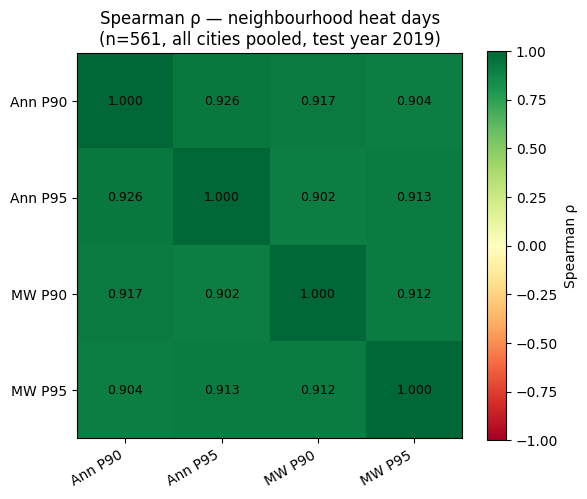

                   Annual P90  Annual P95  Moving-window P90  Moving-window P95
Annual P90              1.000       0.926              0.917              0.904
Annual P95              0.926       1.000              0.902              0.913
Moving-window P90       0.917       0.902              1.000              0.912
Moving-window P95       0.904       0.913              0.912              1.000


In [34]:
# Drop rows with any NaN across variants before computing correlation
df_corr = gdf_all[VARIANT_NAMES].dropna()
n_valid = len(df_corr)

corr_mat = np.full((4, 4), np.nan)
for i, vi in enumerate(VARIANT_NAMES):
    for j, vj in enumerate(VARIANT_NAMES):
        if i == j:
            corr_mat[i, j] = 1.0
        else:
            rho, _ = spearmanr(df_corr[vi], df_corr[vj])
            corr_mat[i, j] = rho

corr_df = pd.DataFrame(
    corr_mat,
    index=[VARIANT_LABELS[v] for v in VARIANT_NAMES],
    columns=[VARIANT_LABELS[v] for v in VARIANT_NAMES]
)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_mat, vmin=-1, vmax=1, cmap='RdYlGn')
plt.colorbar(im, ax=ax, label='Spearman ρ')
ax.set_xticks(range(4))
ax.set_yticks(range(4))
labels_short = ['Ann P90', 'Ann P95', 'MW P90', 'MW P95']
ax.set_xticklabels(labels_short, rotation=30, ha='right')
ax.set_yticklabels(labels_short)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{corr_mat[i, j]:.3f}', ha='center', va='center',
                fontsize=9, color='black')
ax.set_title(f'Spearman ρ — neighbourhood heat days\n'
             f'(n={n_valid}, all cities pooled, test year {TEST_YEAR})')
plt.tight_layout()
plt.show()

print(corr_df.round(3).to_string())

### 6b. Scatter Plots: Annual vs Moving-Window
One panel per city, two scatter pairs (P90 and P95).

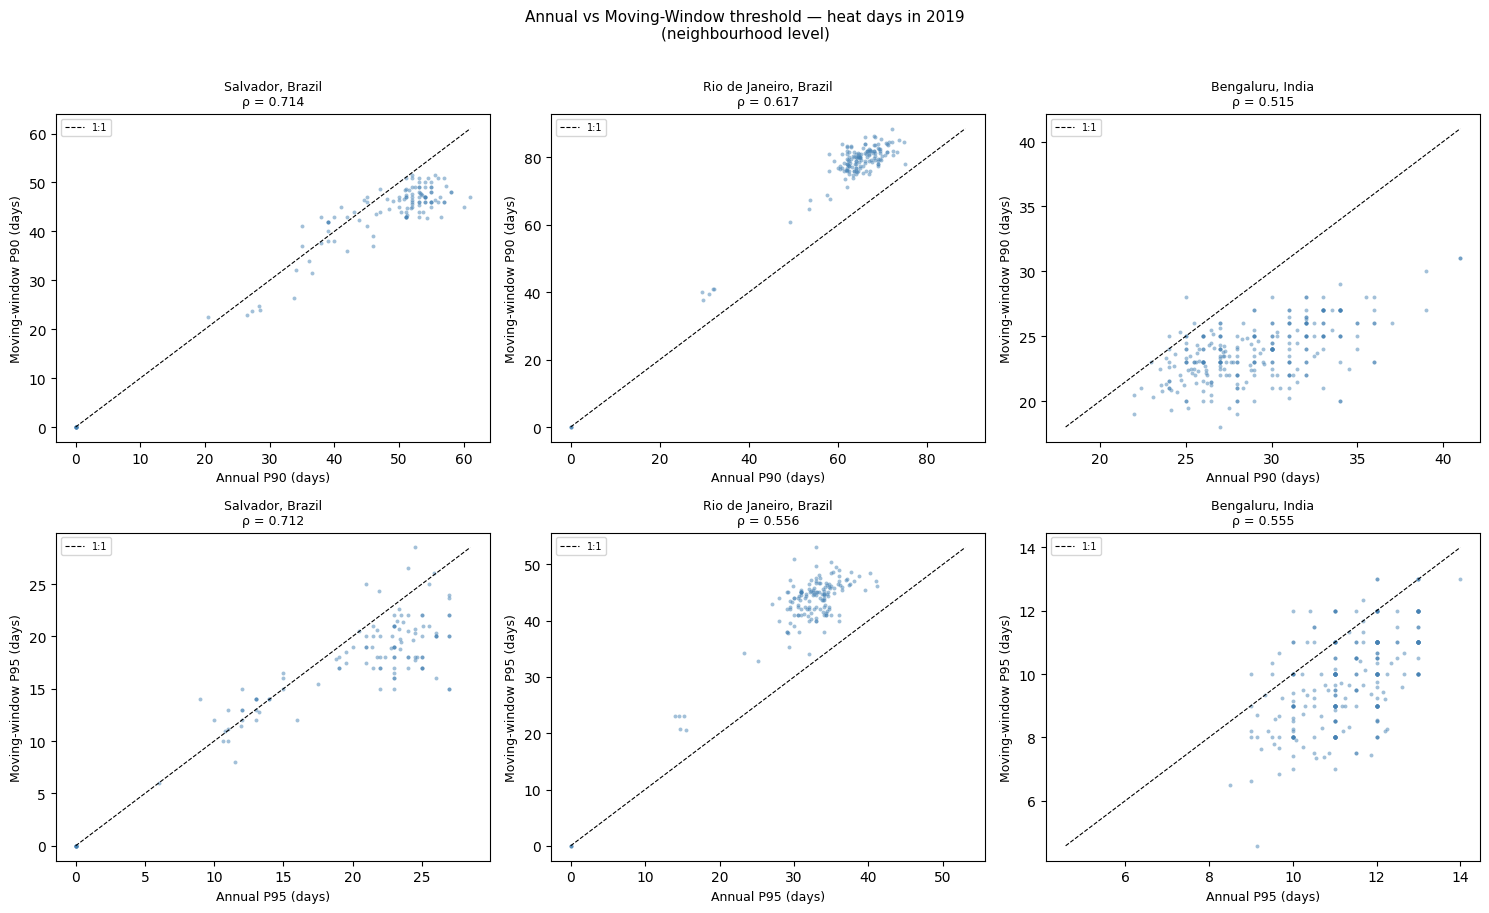

In [35]:
cities_plotted = [k for k in gdf_by_city if k in heat_days]
n_cities = len(cities_plotted)

if n_cities == 0:
    print('No cities available for scatter plots.')
else:
    fig, axes = plt.subplots(
        2, max(n_cities, 1),
        figsize=(5 * max(n_cities, 1), 9),
        squeeze=False
    )

    for col, city_key in enumerate(cities_plotted):
        gdf_c = gdf_by_city[city_key].dropna(subset=VARIANT_NAMES)
        label = CITIES[city_key]['label']

        for row, (ann_v, mw_v, pct_label) in enumerate([
            ('ann_p90', 'mw_p90', 'P90'),
            ('ann_p95', 'mw_p95', 'P95'),
        ]):
            ax = axes[row][col]
            x = gdf_c[ann_v]
            y = gdf_c[mw_v]

            ax.scatter(x, y, s=8, alpha=0.5, color='steelblue', linewidths=0)

            # 1:1 line
            lo = min(x.min(), y.min())
            hi = max(x.max(), y.max())
            ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, label='1:1')

            rho, _ = spearmanr(x, y)
            ax.set_xlabel(f'Annual {pct_label} (days)', fontsize=9)
            ax.set_ylabel(f'Moving-window {pct_label} (days)', fontsize=9)
            ax.set_title(f'{label}\nρ = {rho:.3f}', fontsize=9)
            ax.legend(fontsize=7)

    plt.suptitle(
        f'Annual vs Moving-Window threshold — heat days in {TEST_YEAR}\n'
        f'(neighbourhood level)',
        y=1.01, fontsize=11
    )
    plt.tight_layout()
    plt.show()

### 6c. Summary Table — Mean and SD of Heat Days per Variant per City

In [36]:
rows = []
for city_key, gdf_c in gdf_by_city.items():
    label = CITIES[city_key]['label']
    for v in VARIANT_NAMES:
        col = gdf_c[v].dropna()
        rows.append({
            'City': label,
            'Variant': VARIANT_LABELS[v],
            'n_nbhd': len(col),
            'Mean (days)': round(col.mean(), 1) if len(col) > 0 else np.nan,
            'SD (days)':   round(col.std(), 1)  if len(col) > 0 else np.nan,
            'Min': round(col.min(), 1) if len(col) > 0 else np.nan,
            'Max': round(col.max(), 1) if len(col) > 0 else np.nan,
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

                  City           Variant  n_nbhd  Mean (days)  SD (days)  Min  Max
      Salvador, Brazil        Annual P90     123    45.799999       14.3  0.0 61.0
      Salvador, Brazil        Annual P95     123    19.500000        7.2  0.0 27.0
      Salvador, Brazil Moving-window P90     123    41.400002       12.5  0.0 51.5
      Salvador, Brazil Moving-window P95     123    16.799999        5.8  0.0 28.5
Rio de Janeiro, Brazil        Annual P90     151    62.900002       11.6  0.0 75.0
Rio de Janeiro, Brazil        Annual P95     151    31.700001        6.2  0.0 41.2
Rio de Janeiro, Brazil Moving-window P90     151    76.500000       13.6  0.0 88.6
Rio de Janeiro, Brazil Moving-window P95     151    42.400002        7.9  0.0 53.0
      Bengaluru, India        Annual P90     287    29.000000        3.5 22.0 41.0
      Bengaluru, India        Annual P95     287    11.300000        1.1  8.5 14.0
      Bengaluru, India Moving-window P90     287    23.799999        2.2 18.0 31.0
    

## Notes

**Base period**: 2003–2020, matching WorldPop population data vintage. Adjust
`BASE_START` / `BASE_END` in Section 0 to change.

**Salvador data coverage**: the existing local file (`gshtd_tmin_salvador_spatial.nc`)
covers 2018–2020 only (3 years). This is insufficient for a 2003–2020 base period
— re-run the GEE acquisition section with `BASE_START = '2003-01-01'` to download
the full period and save to `data/salvador_tmin.nc`.

**GEE sub-collection paths** (Zhang et al. GSHTD):
- Brazil cities → `latin_america`
- Bengaluru → `europe_asia` (covers South and Southeast Asia)
- Other regions: `africa`, `australia`, `north_america`

**Moving-window vs xclim**: the `moving_window_percentile_doy` function replicates
`xclim.core.calendar.percentile_doy(window=5, bootstrap=False)` in pure NumPy so
it runs in the `gee` conda environment without needing `xclim`. For large grids
(> 500 × 500 pixels) the DOY loop may be slow — vectorise the inner loop or
switch to xclim in the `hit` environment if performance is a concern.

**Zonal aggregation**: point-in-polygon join assigns each 1 km pixel centroid
to the neighbourhood that contains it. Pixels on neighbourhood boundaries will
be assigned to whichever polygon is first matched; adjust `predicate='within'`
to `predicate='intersects'` in `zonal_mean` if you want boundary pixels counted.